# Complete Case Analysis(CAA), Removing missing value row

### Loading, and Analyzing dataset

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv('E:/Dataset/data_science_job.csv')

In [3]:
df.sample(3)

,enrollee_id,city,city_development_index,gender,relevent_experience,enrolled_university,education_level,major_discipline,experience,company_size,company_type,training_hours,target
5714,7049,city_16,0.910,Male,No relevent experience,Part time course,Graduate,STEM,7.0,50-99,Pvt Ltd,50.0,0.0
16065,21620,city_21,0.624,Female,Has relevent experience,Full time course,Graduate,STEM,3.0,50-99,Pvt Ltd,15.0,1.0
17850,12061,city_16,0.910,Female,Has relevent experience,no_enrollment,Graduate,STEM,4.0,10000+,Other,47.0,0.0


In [4]:
df.isnull().sum()

enrollee_id                  0
city                         0
city_development_index     479
gender                    4508
relevent_experience          0
enrolled_university        386
education_level            460
major_discipline          2813
experience                  65
company_size              5938
company_type              6140
training_hours             766
target                       0
dtype: int64

In [5]:
df.shape

(19158, 13)

In [6]:
df.isnull().mean()*100

enrollee_id                0.000000
city                       0.000000
city_development_index     2.500261
gender                    23.530640
relevent_experience        0.000000
enrolled_university        2.014824
education_level            2.401086
major_discipline          14.683161
experience                 0.339284
company_size              30.994885
company_type              32.049274
training_hours             3.998330
target                     0.000000
dtype: float64

### Dropping columns

In [7]:
cols = [var for var in df.columns if df[var].isnull().mean()<0.05 and df[var].isnull().mean()>0]
cols

['city_development_index',
 'enrolled_university',
 'education_level',
 'experience',
 'training_hours']

In [8]:
df[cols].sample(4)

,city_development_index,enrolled_university,education_level,experience,training_hours
7216,0.910,no_enrollment,Graduate,8.0,15.0
1172,0.887,no_enrollment,Masters,5.0,218.0
18862,0.624,Full time course,High School,1.0,45.0
2742,NaN,Full time course,Graduate,6.0,55.0


In [9]:
len(df[cols].dropna())/len(df)

0.8968577095730244

In [10]:
new_df = df[cols].dropna()

In [11]:
df.shape, new_df.shape

((19158, 13), (17182, 5))

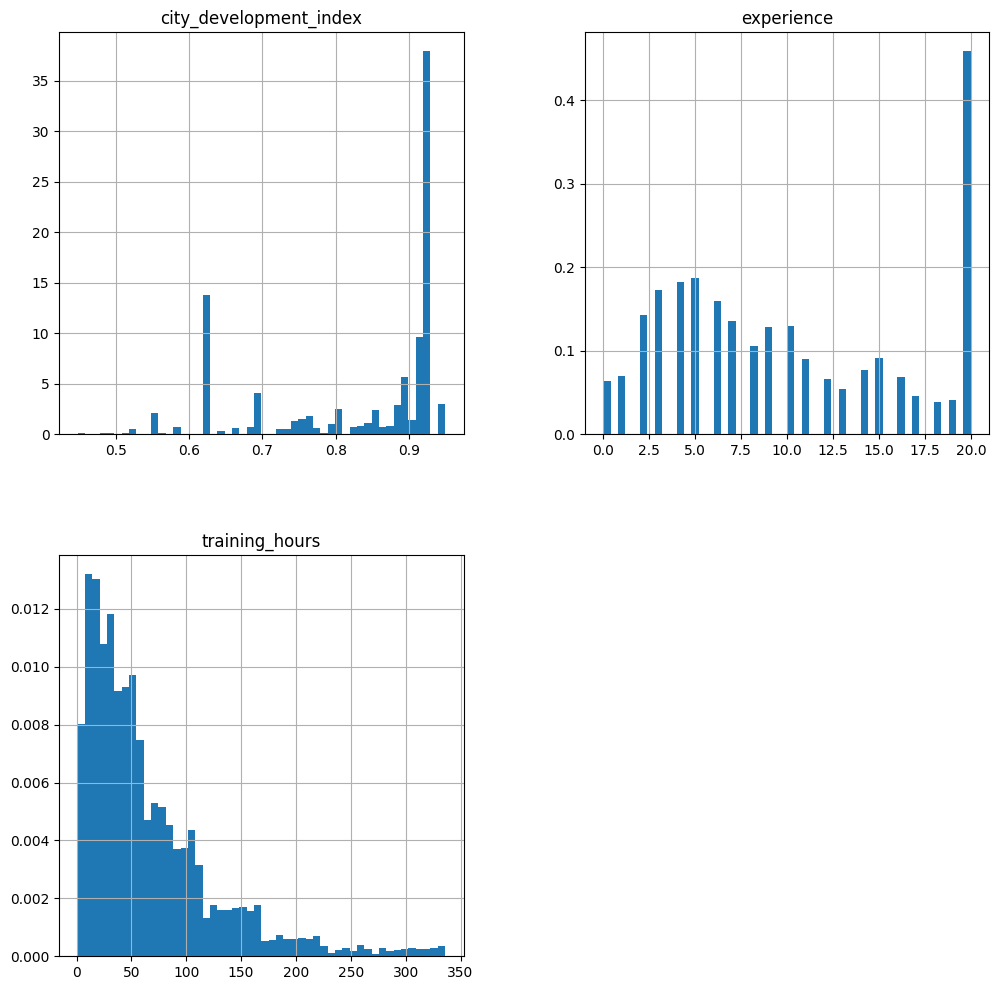

In [12]:
new_df.hist(bins=50, density=True, figsize=(12, 12))
plt.show()

### Analyzing dataset before, and after dropping rows which have missing values

#### For numerical columns

<Axes: >

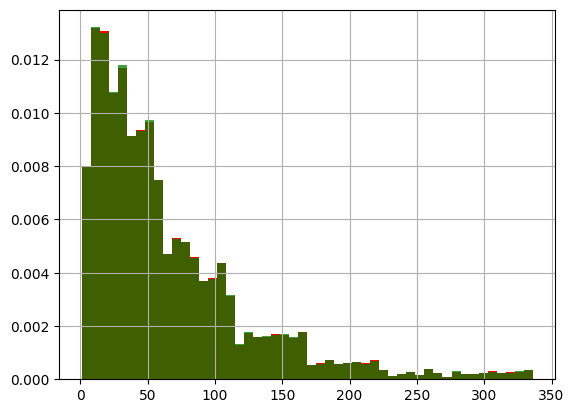

In [13]:
df['training_hours'].hist(bins=50, density=True, color='red')
new_df['training_hours'].hist(bins=50, density=True, color='green', alpha=0.75)

<Axes: ylabel='Density'>

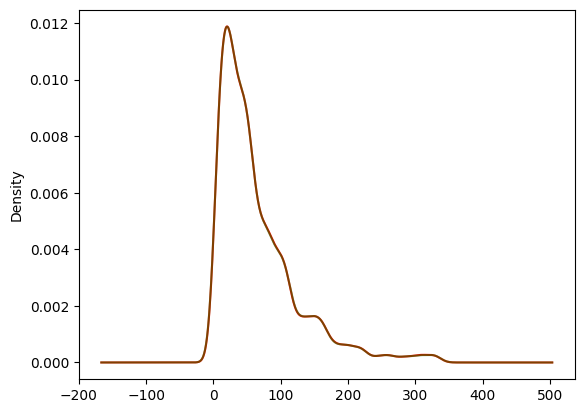

In [14]:
df['training_hours'].plot.density(color='red')
new_df['training_hours'].plot.density(color='green', alpha=0.5)

<Axes: >

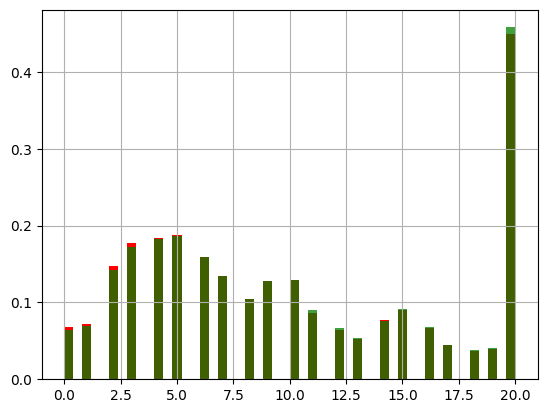

In [15]:
df['experience'].hist(bins=50, color='red', density=True)
new_df['experience'].hist(bins=50, color='green', alpha=0.75, density=True)

<Axes: ylabel='Density'>

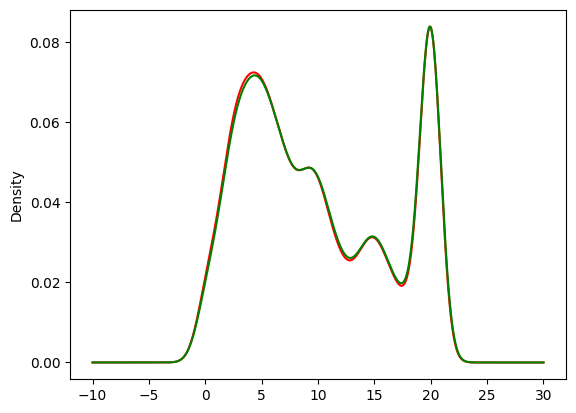

In [16]:
df['experience'].plot(kind='kde', color='red')
new_df['experience'].plot(kind='kde', color='green')

#### For categorical columns

In [17]:
# percentage of observation per category
temp_un = pd.concat([
    # original data
    df['enrolled_university'].value_counts()/len(df),
    # after CCA data
    new_df['enrolled_university'].value_counts()/len(new_df)
], axis=1)

# Add columns name
temp_un.columns = ['original', 'after_cca']

temp_un

,original,after_cca
enrolled_university,,
no_enrollment,0.721213,0.735188
Full time course,0.196106,0.200733
Part time course,0.062533,0.064079


In [18]:
temp_ed = pd.concat([
    df['education_level'].value_counts()/len(df),
    new_df['education_level'].value_counts()/len(new_df)
], axis=1)

temp_ed.columns = ['original', 'after_CCA']

temp_ed

,original,after_CCA
education_level,,
Graduate,0.605387,0.619835
Masters,0.227633,0.234082
High School,0.105282,0.107380
Phd,0.021610,0.022116
Primary School,0.016077,0.016587
